In [53]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

%matplotlib inline

## Main Steps when building a Machine Learning Model. 
1. Inspect and explore data.
2. Select and engineer features.
3. Build and train model.
4. Evaluate model.

# #1 Inspect and explore data.
* Load titanic data
* Visualize all the data using sns.pairplot
* Check for null values

In [2]:
# Load in the titanic data set.
df = pd.read_csv("../data/titanic.csv")

In [3]:
df.head(3)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
# Check for null values
df.isnull().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age            177
sibsp            0
parch            0
ticket           0
fare             0
cabin          687
embarked         2
dtype: int64

In [5]:
df = df.dropna(subset=['embarked'])

# #2 Select and engineer features.
1. Fill age null values with -999
1. Convert to numerical values if need be by using `pd.get_dummies()`
1. Create a list of the features you are going to use.  In this case use as many or as little as you would like.
1. Define our `X` and `y`
1. Split our data into trainig and testing sets.

In [6]:
# Fill age null values with -999
df['age'] = df['age'].fillna(-999)

In [7]:
df['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [8]:
# 1. Convert to numerical values if need be by using `pd.get_dummies()`
df = pd.get_dummies(df, columns=['sex','embarked'])

In [9]:
df.head(2)

,passengerid,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,True,False,True,False,False


In [10]:
# 2. Create a list of the features we are going to use.
selected_features = df[['pclass','age','sibsp','parch','fare','sex_female',
                        'sex_male','embarked_C','embarked_Q','embarked_S']]

In [11]:
# Define our `X` and `y`
X = selected_features
y = df['survived']

In [12]:
# Split our data into trainig and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Lenght of our Training data:', X_train.shape[0], '\nLength of our Testing data:', X_test.shape[0])

Lenght of our Training data: 711 
Length of our Testing data: 178


# #3 Build and train model.
1. For our first pass, initialize our model with `max_depth=2`.
2. Fit our model with our training data. 
3. Make predictions of our testing data. 
4. Evaluate and print our model scores using accuracy, precision, recall, f1 scores, and auc scores. 
    * To calculate auc score you have to get the predicted probabilites for the Survived class using `model.predict_proba(X_test)[:,1]`
5. Visualize our Decision Tree using provided code. 


In [13]:
# For our first pass, initialize our model with `max_depth=2`.
model = DecisionTreeClassifier(max_depth=2, random_state=42)


In [14]:
# Fit our model with our training data. 
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [15]:
# Make predictions of our testing data. 
y_pred = model.predict(X_test)


In [16]:
# Predict labels
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision Score: %f" % precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall Score: %f" % recall)

# F1 Score
f1 = f1_score(y_test, y_pred)
print('F1 Score: %f' % f1)

# Predicted probabilities
y_pred_proba = model.predict_proba(X_test)  # probabilities for each class
y_pred_proba = y_pred_proba[:, 1]           # probability of positive class (1)

# AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)


Accuracy Score: 0.797753
Precision Score: 0.726027
Recall Score: 0.768116
F1 Score: 0.746479
AUC Score: 0.849953


# Visualize your tree

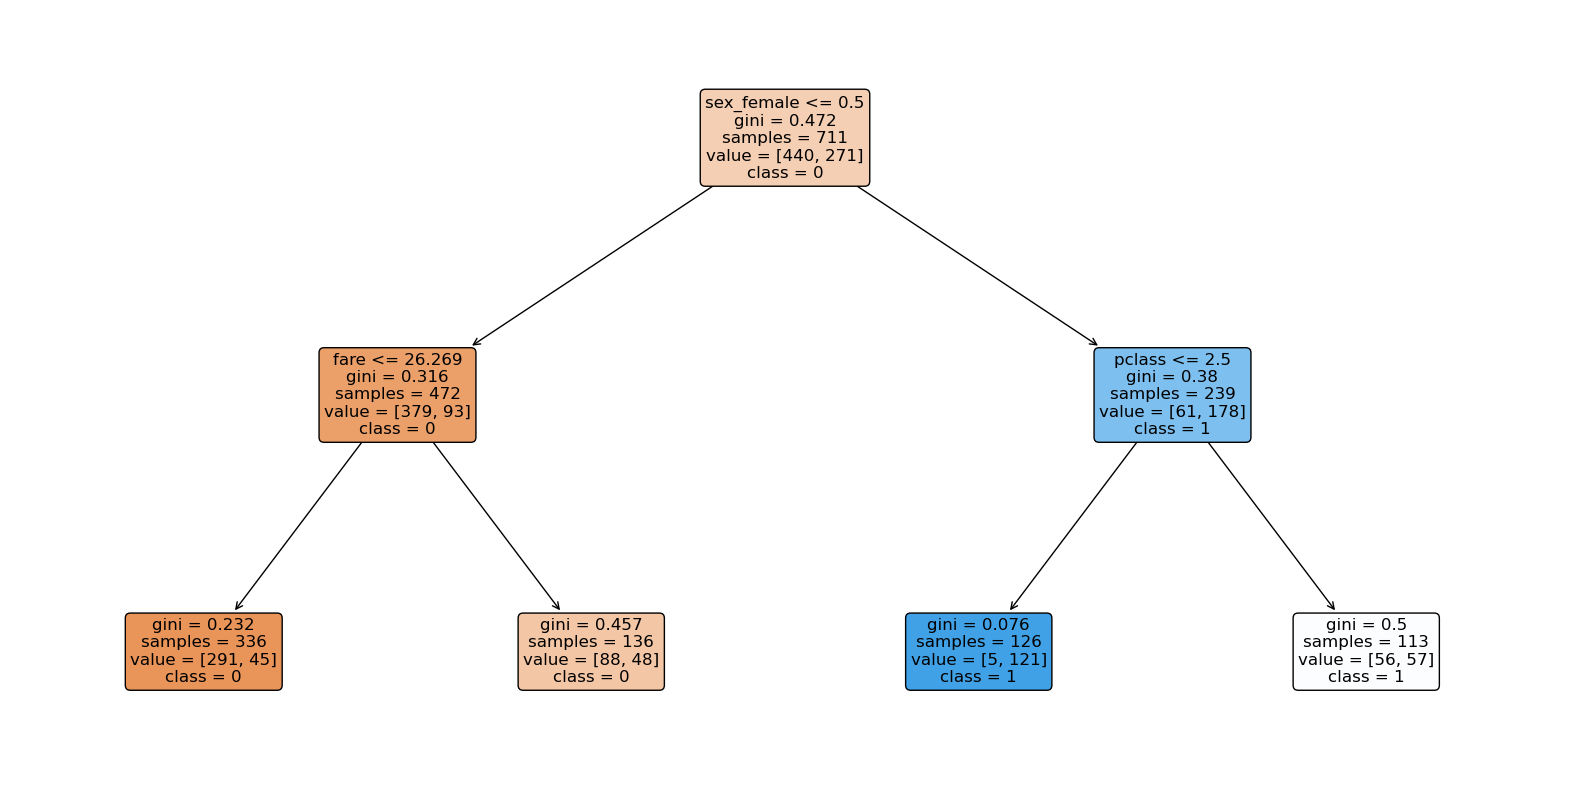

In [17]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=list(X_train.columns),  # use your column names
    class_names=['0','1'],          # for binary classification
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()

# Picking the right parameters...

# Parameter tuning of your Decision Tree using GridSearch or RandomizedSearch

### For assistance on this, look at Steves TA Tips code in `TA-Tips/random_forest_tuning.ipynb`


1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Visualize your best tree.
1. Which feature was your most important feature?

```python
tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    class_weight=None,
    presort='deprecated',
    ccp_alpha=0.0,
)
```


[Tips on how to customize / set the paramters in the decision tree.](https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use)

In [18]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search.from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

dt = DecisionTreeClassifier(random_state=42)


In [19]:
# 1. Initalize your GridSearchCV with a DecisionTreeClassifier, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='accuracy', 
    cv=5,             
    n_jobs=-1,
    verbose=1
)

In [20]:
# 1. Fit your GridSearchCV with your training data. 
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [21]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [22]:
# 1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 

# This command gives you the best tree
model = grid_search.best_estimator_

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Calculate predicted probabilities, keep only probability for when class = 1
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8089887640449438
Precision: 0.7777777777777778
Recall: 0.7101449275362319
F1 Score: 0.7424242424242424
ROC AUC: 0.839981385454062


In [23]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
importances = model.feature_importances_
feature_importances = sorted(zip(X_train.columns, importances), key=lambda x: x[1], reverse=True)
print("Feature Importances:", feature_importances)

Feature Importances: [('sex_female', 0.5141119473758095), ('fare', 0.16176863014450832), ('pclass', 0.1337276436912145), ('age', 0.10648270387754943), ('sibsp', 0.03792230088178696), ('parch', 0.031893440842904984), ('embarked_S', 0.009413105717577428), ('embarked_C', 0.00468022746864886), ('sex_male', 0.0), ('embarked_Q', 0.0)]


# Now onto Random Forests...
Were going to do the same with, but this time with a random forest. Remeber... Repetition is the father of learning.

1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
1. Initalize your GridSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
1. Fit your GridSearchCV with your training data. 
1. Print the parameters of your best model. 
1. Evaluate your best model using accuracy, precision, recall, f1 scores, and auc scores. 
1. Which feature was your most important feature?


# Parameters of the Random Forest Classifier

```python
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='auto',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_impurity_split=None,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
)
```

In [24]:
# 1. Make a dictionary of at least 3 parameters and a list of 3 values for each for your grid search. 
param_grid = {
    'n_estimators': range(10,200,50),         
    'max_depth': range(1,10,3),             
    'min_samples_split': range(1,10,3),         
    'min_samples_leaf': range(1,10,4),          
}

In [25]:
# 1. Initalize your GridSearchCV or RandomizedSearchCV with a RandomForestClassifer, your param_grid, and what you are optimizing for.  Choose any of the five optimization strategies; accuracy, precision, recall, f1, or roc_auc.
rf = RandomForestClassifier(random_state=42)

# --- 3. Initialize GridSearchCV ---
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',       # choose any metric: 'precision', 'recall', 'f1', 'roc_auc'
    cv=3,                     # 3-fold cross-validation
    n_jobs=-1,                # use all CPU cores
    verbose=2
)

In [26]:
# 1. Fit your GridSearchCV with your training data. 
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
108 fits failed out of a total of 324.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
108 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Bagdo\anaconda3\Lib\site-packag

Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 60}


In [30]:
# 1. Print the parameters of your best model. 
# Print the best parameters it found
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 60}


In [32]:
model = grid_search.best_estimator_

y_pred = model.predict(X_test)

# --- 7. Evaluate performance ---
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred)
print('F1 Score: %f' % f1)

# --- 8. AUC score ---
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.814607
Precision Score: 0.772727
Recall Score: 0.739130
F1 Score: 0.755556
AUC Score: 0.852746


In [35]:
# 1. Which feature was your most important feature?
# Now lets look at our feature importances
feature_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_imp


sex_male      0.241356
sex_female    0.195723
fare          0.169098
pclass        0.132686
age           0.109145
sibsp         0.061125
parch         0.045622
embarked_C    0.020107
embarked_S    0.016863
embarked_Q    0.008276
dtype: float64

# Build a random forest using the ny-vs-sf-housing.csv data. 
* Your target variable, aka the column you are trying to predict, aka your `y` variable is `in_sf`. 
* Can you get an accuracy above %88.8889?
* What was your most important feature?


In [37]:
df = pd.read_csv('../data/ny-vs-sf-houses.csv')
df.head()

,in_sf,beds,bath,price,year_built,sqft,price_per_sqft,elevation
0,0,2.0,1.0,999000,1960,1000,999,10
1,0,2.0,2.0,2750000,2006,1418,1939,0
2,0,2.0,2.0,1350000,1900,2150,628,9
3,0,1.0,1.0,629000,1903,500,1258,9
4,0,0.0,1.0,439000,1930,500,878,10


In [ ]:
# BUILD, TRAIN, AND EVAULATE A RANDOM FOREST MODEL BELOW. 

**Adding new features**

In [54]:
df['bed_bath_ratio'] = df['beds'] / (df['bath'] + 1)
df['price_sqft_ratio'] = df['price'] / (df['sqft'] + 1)
df['log_price'] = np.log1p(df['price'])
df['log_sqft'] = np.log1p(df['sqft'])
df['age'] = 2025 - df['year_built']

In [56]:
X = df[['beds','bath','price','sqft','price_per_sqft','elevation','bed_bath_ratio','price_sqft_ratio','log_price', 'age']]
y = df['in_sf']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',       
    cv=3,                     
    n_jobs=-1,                
    verbose=2
)


In [ ]:
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

In [68]:
model =  grid_search.best_estimator_

In [69]:
y_pred = model.predict(X_test)

# --- 7. Evaluate performance ---
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred)
print('F1 Score: %f' % f1)

# --- 8. AUC score ---
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.898990
Precision Score: 0.883333
Recall Score: 0.946429
F1 Score: 0.913793
AUC Score: 0.961379


In [67]:
feature_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_imp


elevation           0.317564
price_per_sqft      0.161687
price_sqft_ratio    0.153103
age                 0.095429
sqft                0.061771
price               0.057875
bed_bath_ratio      0.057742
log_price           0.056308
beds                0.023395
bath                0.015126
dtype: float64

**Gradient Boosting**

In [70]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.05,
    n_estimators=500,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))


Accuracy: 0.9292929292929293
AUC: 0.9671926910299004


# Awesome difficult extra credit below:
Build a classifier using the adult_income.csv data.  
* The target variable is 'class'
* Start with just using these features `selected_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']`
* You have to include the pos_label in your precision, recall, and f1 scores. It just tells the classifier which one is the posotive label.  I provided the proper way below.

* See if you can get above 50% f1 score.  
* See some [super tricks and tips here](https://www.kaggle.com/code/jieyima/income-classification-model)

In [94]:
df = pd.read_csv('../data/adult_income.csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [95]:
df['workclass'].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [96]:
df = pd.get_dummies(df, columns=['sex','race','workclass'])

In [98]:
df.columns

Index(['age', 'fnlwgt', 'education', 'education_num', 'marital_status',
       'occupation', 'relationship', 'capital_gain', 'capital_loss',
       'hours_per_week', 'native_country', 'class', 'sex_ Female', 'sex_ Male',
       'race_ Amer-Indian-Eskimo', 'race_ Asian-Pac-Islander', 'race_ Black',
       'race_ Other', 'race_ White', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay'],
      dtype='object')

In [99]:
X = df[['age','fnlwgt','sex_ Female', 'sex_ Male',
       'race_ Amer-Indian-Eskimo', 'race_ Asian-Pac-Islander', 'race_ Black',
       'race_ Other', 'race_ White', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay','education_num','capital_gain',	
        'capital_loss',	'hours_per_week']]

In [101]:
y = df['class']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [103]:
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',       
    cv=3,                     
    n_jobs=-1,                
    verbose=2
)


In [104]:
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
324 fits failed out of a total of 972.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
106 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\base.py", line 1144, in wrapper
    estimator._validate_params()
  File "C:\Users\Bagdo\anaconda3\Lib\site-packages\sklearn\base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Bagdo\anaconda3\Lib\site-packag

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [106]:
model =  grid_search.best_estimator_
y_pred = model.predict(X_test)
# --- 7. Evaluate performance ---
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: %f" % accuracy)

precision = precision_score(y_test, y_pred)
print("Precision Score: %f" % precision)

recall = recall_score(y_test, y_pred)
print("Recall Score: %f" % recall)

f1 = f1_score(y_test, y_pred)
print('F1 Score: %f' % f1)

# --- 8. AUC score ---
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print('AUC Score: %f' % auc)

Accuracy Score: 0.846461


ValueError: pos_label=1 is not a valid label. It should be one of [' <=50K', ' >50K']